# V4b: model-guided Pair Generator

В этом ноутбуке проверяется ветка, где `Preference Model` начинает участвовать в выборе следующей A/B-пары.

Идея эксперимента:

- `Candidate Generator` создаёт много пар в разных направлениях и с разным масштабом;
- `Preference Model` оценивает неопределённость пары через `P(A > B)`;
- `Pair Selector` выбирает пару либо почти полностью по модели (`model_only`), либо по гибридному score (`proxy_score + model_uncertainty`).

Важно: чтобы не было совсем нечестного cold start, в эксперимент добавлены два способа стабилизации:

1. `model_only_warmup` — первые шаги делает `Semantic active v3`, затем управление переходит модели;
2. `*_pretrained` — модель получает слабый population prior из отдельно сгенерированной synthetic-population. Это не индивидуальный target пользователя, а только слабый prior / предкалибровка feature weights.


In [1]:
from personalization.plotting import use_article_style
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from personalization.model_guided_pair_generation import (
    MODEL_GUIDED_STRATEGY_DISPLAY_NAMES,
    TARGET_MODE_DISPLAY_NAMES,
    build_population_preference_prior,
    run_model_guided_pair_batch_v4b,
    save_v4b_outputs,
    summarize_model_guided_sessions,
)
from personalization.synthetic_dataset import load_synthetic_users_dataset

use_article_style()


plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "font.size": 11,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

DATASET_PATH = ROOT / "outputs" / "datasets" / "synthetic_users_v21.csv"
OUTPUT_DIR = ROOT / "outputs" / "metrics"
FIGURE_DIR = ROOT / "outputs" / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

dataset = load_synthetic_users_dataset(DATASET_PATH)
dataset["target_mode"].value_counts()

target_mode
random8d       100
semantic4d     100
semantic6d     100
archetype8d    100
Name: count, dtype: int64

## Population prior для модели

Здесь prior строится на отдельной synthetic-population с другим seed. Он нужен не для угадывания конкретного пользователя, а как аналог предварительной калибровки модели на прошлых сессиях.

По умолчанию `z_pref` остаётся нулевым, а из population prior берутся только средние `feature_weight`. Это более честно, чем подмешивать средний target текущего evaluation dataset.


In [2]:
prior = build_population_preference_prior(
    n_per_mode=250,
    seed=2026,
    use_zero_target_prior=True,
)

print("Population prior users:", prior.n_users)
print("Feature weight prior:", np.round(prior.feature_weight, 3))
print("Initial z_pref prior:", np.round(prior.z_pref, 3))

Population prior users: 1000
Feature weight prior: [0.991 1.017 1.01  0.981 0.996 1.003 0.99  1.013]
Initial z_pref prior: [0. 0. 0. 0. 0. 0. 0. 0.]


## Запуск batch-эксперимента

Стратегии:

- `Semantic active v3` — текущий лучший эвристический Pair Generator;
- `Candidate pool active` — смешанный эвристический candidate-pool;
- `Model-only cold` — модель выбирает пару с первого шага;
- `Model-only warmup` — первые 5 шагов semantic-active, затем модель;
- `Model-only pretrained prior` — model-only со слабым population prior;
- `Hybrid model-guided` — proxy-score + неопределённость модели;
- `Hybrid model-guided pretrained` — то же, но со слабым population prior.


In [3]:
# Для быстрого теста можно временно раскомментировать:
# eval_dataset = dataset.groupby("target_mode", group_keys=False).head(20).reset_index(drop=True)

eval_dataset = dataset.copy()

sessions, steps = run_model_guided_pair_batch_v4b(
    dataset=eval_dataset,
    n_steps=25,
    warmup_steps=5,
    step_scale=0.6,
    heuristic_lr=0.25,
    model_lr=0.06,
    model_temperature=0.75,
    model_l2=0.003,
    prior=prior,
)

summary = summarize_model_guided_sessions(sessions)

save_v4b_outputs(
    sessions=sessions,
    steps=steps,
    summary=summary,
    output_dir=OUTPUT_DIR,
    prefix="notebook_v4b_model_guided_pair_generator",
)

summary.head()

,target_mode,strategy,strategy_display,final_vector_method,users,mean_initial_distance,mean_final_distance,std_final_distance,mean_best_distance,mean_mean_distance,mean_improvement_pct,mean_cosine_to_target,mean_train_accuracy_proxy
0,archetype8d,candidate_pool_active,Candidate pool active,heuristic_update,100,1.102635,0.517119,0.192588,0.362425,0.630080,40.795846,0.858622,NaN
1,archetype8d,hybrid_model_guided,Hybrid model-guided,blend_70h_30m,100,1.102635,0.467114,0.206039,0.361469,0.617763,49.508684,0.896266,0.5196
2,archetype8d,hybrid_model_guided,Hybrid model-guided,heuristic_update,100,1.102635,0.493914,0.205709,0.361469,0.617763,45.780729,0.873277,0.5196
3,archetype8d,hybrid_model_guided,Hybrid model-guided,norm_calibrated_model,100,1.102635,0.463009,0.253628,0.361469,0.617763,51.483836,0.907447,0.5196
4,archetype8d,hybrid_model_guided,Hybrid model-guided,raw_preference_model,100,1.102635,0.659658,0.396729,0.361469,0.617763,40.371520,0.907447,0.5196


## 1. Сравнение Pair Generator по heuristic final vector

Для честного сравнения именно генераторов сначала смотрим `final_vector_method = heuristic_update`. Тогда мы измеряем, насколько разные способы выбора A/B-пар улучшают траекторию обычного preference state.


In [4]:
def display_target_mode(mode: str) -> str:
    return TARGET_MODE_DISPLAY_NAMES.get(mode, mode)

STRATEGY_ORDER = [
    "semantic_active_v21",
    "candidate_pool_active",
    "model_only_cold",
    "model_only_warmup",
    "model_only_pretrained",
    "hybrid_model_guided",
    "hybrid_model_guided_pretrained",
]

heuristic_summary = summary[summary["final_vector_method"] == "heuristic_update"].copy()
heuristic_summary["target_mode_display"] = heuristic_summary["target_mode"].map(display_target_mode)
heuristic_summary["strategy_display"] = heuristic_summary["strategy"].map(MODEL_GUIDED_STRATEGY_DISPLAY_NAMES)

pivot = heuristic_summary.pivot_table(
    index="target_mode_display",
    columns="strategy_display",
    values="mean_final_distance",
)
ordered_cols = [MODEL_GUIDED_STRATEGY_DISPLAY_NAMES[s] for s in STRATEGY_ORDER if MODEL_GUIDED_STRATEGY_DISPLAY_NAMES[s] in pivot.columns]
pivot = pivot[ordered_cols]
pivot

strategy_display,Semantic active v3,Candidate pool active,Model-only cold,Model-only warmup,Model-only pretrained prior,Hybrid model-guided,Hybrid model-guided pretrained
target_mode_display,,,,,,,
Archetype 8D,0.370540,0.517119,0.784102,0.786169,0.804284,0.493914,0.490722
Random 8D,1.509992,1.020938,1.221019,1.221839,1.212566,1.281911,1.315806
Semantic 4D,0.415562,0.590519,0.859714,0.839221,0.862814,0.580108,0.575586
Semantic 6D,0.548109,0.887728,1.244816,1.185924,1.228185,0.798754,0.808149


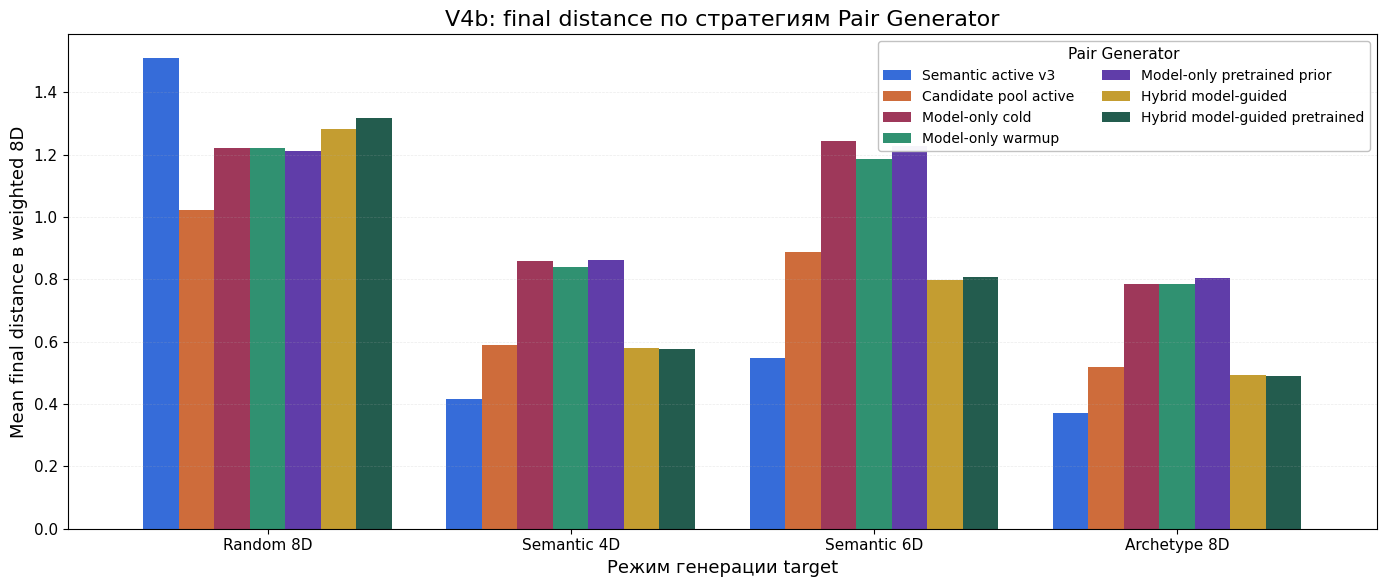

In [5]:
def plot_heuristic_final_distance_by_target(heuristic_summary):
    df = heuristic_summary.copy()
    order_modes = ["Random 8D", "Semantic 4D", "Semantic 6D", "Archetype 8D"]
    pivot = df.pivot_table(
        index="target_mode_display",
        columns="strategy_display",
        values="mean_final_distance",
    ).reindex(order_modes)
    ordered_cols = [MODEL_GUIDED_STRATEGY_DISPLAY_NAMES[s] for s in STRATEGY_ORDER if MODEL_GUIDED_STRATEGY_DISPLAY_NAMES[s] in pivot.columns]
    pivot = pivot[ordered_cols]

    fig, ax = plt.subplots(figsize=(14, 6), facecolor="white")
    pivot.plot(kind="bar", ax=ax, width=0.82)
    ax.set_title("V4b: final distance по стратегиям Pair Generator")
    ax.set_xlabel("Режим генерации target")
    ax.set_ylabel("Mean final distance в weighted 8D")
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    ax.legend(title="Pair Generator", ncol=2, frameon=True, facecolor="white", edgecolor="0.75")
    plt.xticks(rotation=0)
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / "article_v4b_pair_generator_final_distance_by_target.png", dpi=200, bbox_inches="tight")
    plt.show()

plot_heuristic_final_distance_by_target(heuristic_summary)

## 2. Ветка model-only: cold start vs warmup vs pretrained prior

Этот график отвечает на вопрос: можно ли полностью доверить выбор пары модели.

Смотрим только `Archetype 8D`, потому что это основной realistic-режим.


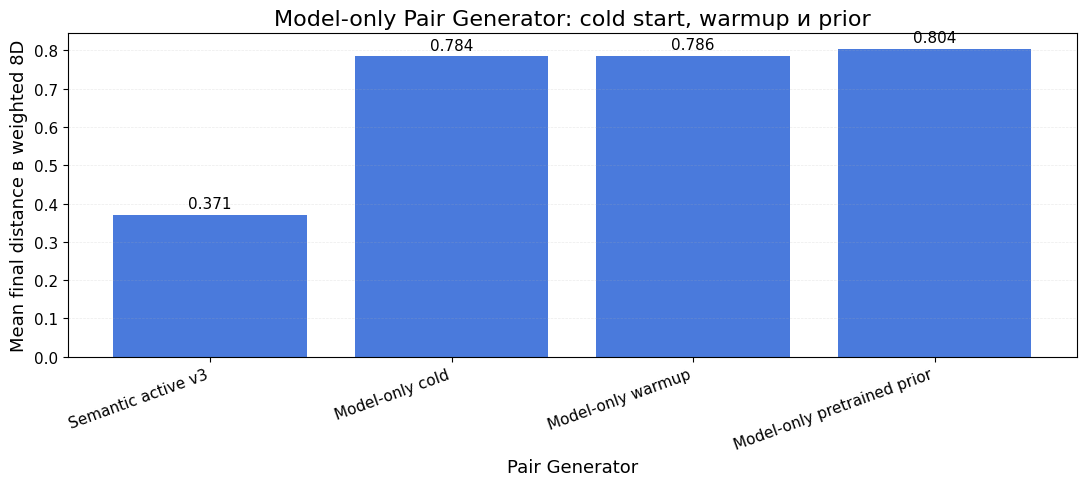

In [6]:
def plot_archetype_model_only_comparison(summary):
    df = summary[
        (summary["target_mode"] == "archetype8d")
        & (summary["final_vector_method"] == "heuristic_update")
        & (summary["strategy"].isin(["semantic_active_v21", "model_only_cold", "model_only_warmup", "model_only_pretrained"]))
    ].copy()
    df["strategy_display"] = df["strategy"].map(MODEL_GUIDED_STRATEGY_DISPLAY_NAMES)
    order = [
        "Semantic active v3",
        "Model-only cold",
        "Model-only warmup",
        "Model-only pretrained prior",
    ]
    df["strategy_display"] = pd.Categorical(df["strategy_display"], categories=order, ordered=True)
    df = df.sort_values("strategy_display")

    fig, ax = plt.subplots(figsize=(11, 5), facecolor="white")
    ax.bar(df["strategy_display"], df["mean_final_distance"], alpha=0.9)
    for x, y in enumerate(df["mean_final_distance"]):
        ax.text(x, y + 0.01, f"{y:.3f}", ha="center", va="bottom")
    ax.set_title("Model-only Pair Generator: cold start, warmup и prior")
    ax.set_xlabel("Pair Generator")
    ax.set_ylabel("Mean final distance в weighted 8D")
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / "article_v4b_model_only_archetype8d.png", dpi=200, bbox_inches="tight")
    plt.show()

plot_archetype_model_only_comparison(summary)

## 3. Hybrid model-guided vs эвристические baselines

Здесь проверяется основная идея V4b: не полностью заменять proxy-метрику моделью, а объединить:

`proxy_score + model_uncertainty + safety`.


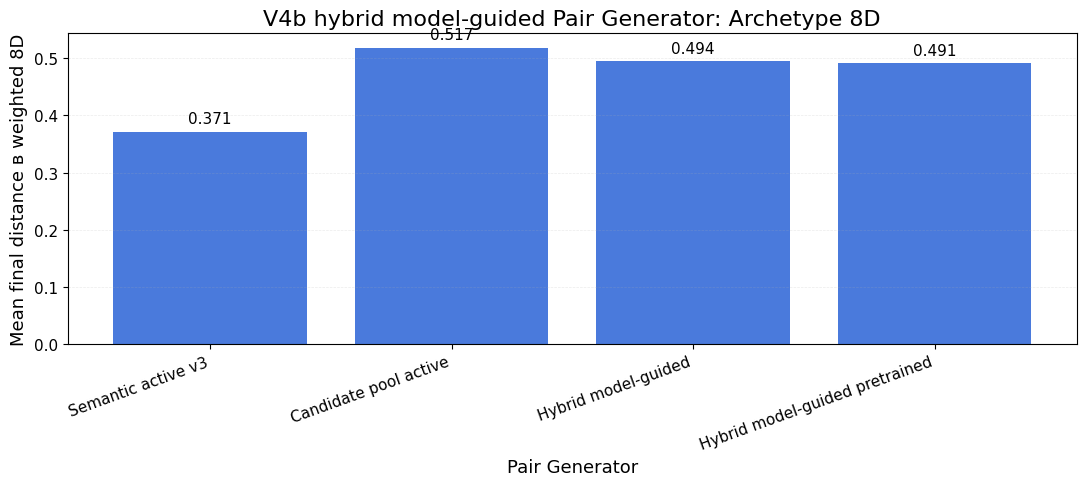

In [7]:
def plot_archetype_hybrid_model_guided(summary):
    df = summary[
        (summary["target_mode"] == "archetype8d")
        & (summary["final_vector_method"] == "heuristic_update")
        & (summary["strategy"].isin([
            "semantic_active_v21",
            "candidate_pool_active",
            "hybrid_model_guided",
            "hybrid_model_guided_pretrained",
        ]))
    ].copy()
    df["strategy_display"] = df["strategy"].map(MODEL_GUIDED_STRATEGY_DISPLAY_NAMES)
    order = [
        "Semantic active v3",
        "Candidate pool active",
        "Hybrid model-guided",
        "Hybrid model-guided pretrained",
    ]
    df["strategy_display"] = pd.Categorical(df["strategy_display"], categories=order, ordered=True)
    df = df.sort_values("strategy_display")

    fig, ax = plt.subplots(figsize=(11, 5), facecolor="white")
    ax.bar(df["strategy_display"], df["mean_final_distance"], alpha=0.9)
    for x, y in enumerate(df["mean_final_distance"]):
        ax.text(x, y + 0.01, f"{y:.3f}", ha="center", va="bottom")
    ax.set_title("V4b hybrid model-guided Pair Generator: Archetype 8D")
    ax.set_xlabel("Pair Generator")
    ax.set_ylabel("Mean final distance в weighted 8D")
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / "article_v4b_hybrid_archetype8d.png", dpi=200, bbox_inches="tight")
    plt.show()

plot_archetype_hybrid_model_guided(summary)

## 4. Динамика сходимости на Archetype 8D

Здесь смотрим, как меняется расстояние по шагам A/B-сессии. Для model-guided стратегий отображается расстояние heuristic state, потому что именно он остаётся текущим центром персонализации во время сессии.


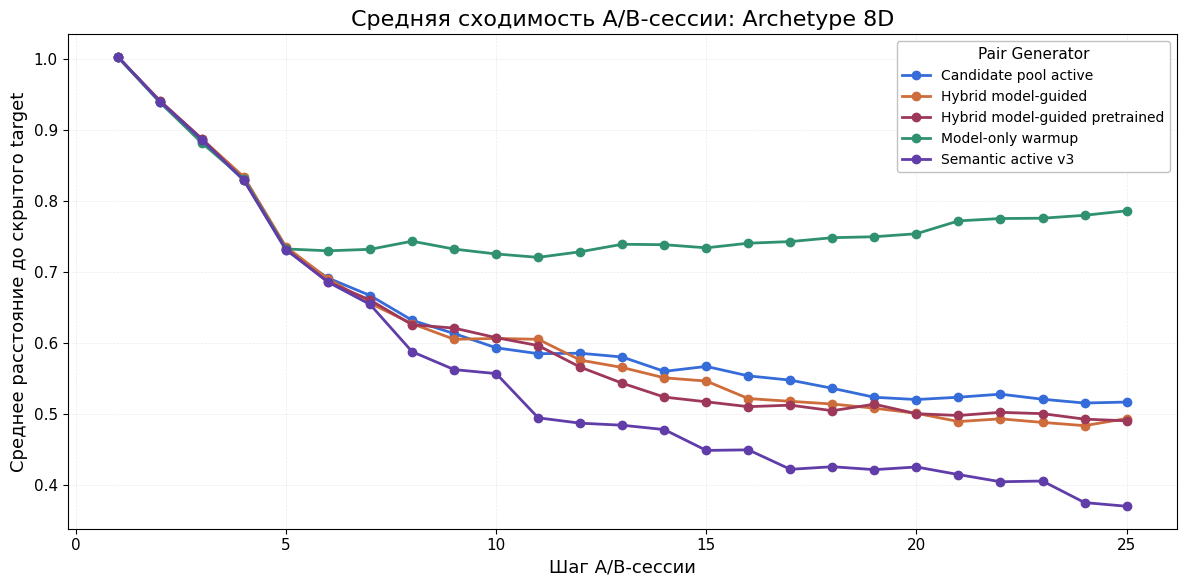

In [8]:
def plot_convergence_archetype(steps):
    df = steps[steps["target_mode"] == "archetype8d"].copy()
    keep = [
        "semantic_active_v21",
        "candidate_pool_active",
        "model_only_warmup",
        "hybrid_model_guided",
        "hybrid_model_guided_pretrained",
    ]
    df = df[df["strategy"].isin(keep)]
    df["strategy_display"] = df["strategy"].map(MODEL_GUIDED_STRATEGY_DISPLAY_NAMES)

    mean_df = (
        df.groupby(["strategy_display", "step"])
        .agg(mean_distance=("distance_to_target", "mean"))
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(12, 6), facecolor="white")
    for strategy_display, part in mean_df.groupby("strategy_display"):
        ax.plot(part["step"], part["mean_distance"], marker="o", linewidth=2, label=strategy_display)
    ax.set_title("Средняя сходимость A/B-сессии: Archetype 8D")
    ax.set_xlabel("Шаг A/B-сессии")
    ax.set_ylabel("Среднее расстояние до скрытого target")
    ax.grid(True, alpha=0.25, linestyle="--")
    ax.legend(title="Pair Generator", frameon=True, facecolor="white", edgecolor="0.75")
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / "article_v4b_convergence_archetype8d.png", dpi=200, bbox_inches="tight")
    plt.show()

plot_convergence_archetype(steps)

## 5. Финальный вектор: heuristic vs calibrated Preference Model

Для model-guided стратегий итоговый preference vector можно брать не только из heuristic state, но и из калиброванной Preference Model. Этот график показывает, помогает ли калибровка уже внутри model-guided генерации.


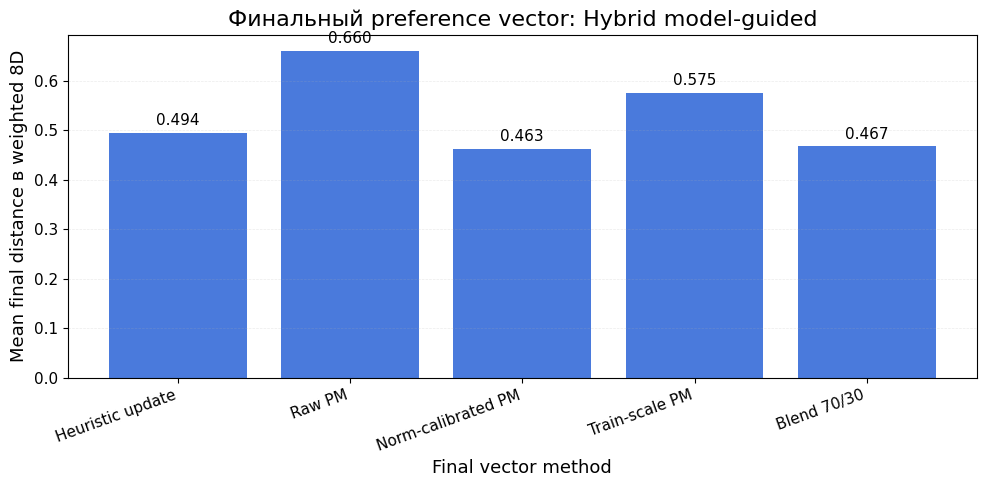

In [9]:
def plot_final_vector_methods_for_strategy(summary, strategy="hybrid_model_guided", target_mode="archetype8d"):
    df = summary[(summary["strategy"] == strategy) & (summary["target_mode"] == target_mode)].copy()
    method_order = [
        "heuristic_update",
        "raw_preference_model",
        "norm_calibrated_model",
        "train_scale_model",
        "blend_70h_30m",
    ]
    method_labels = {
        "heuristic_update": "Heuristic update",
        "raw_preference_model": "Raw PM",
        "norm_calibrated_model": "Norm-calibrated PM",
        "train_scale_model": "Train-scale PM",
        "blend_70h_30m": "Blend 70/30",
    }
    df["method_display"] = df["final_vector_method"].map(method_labels)
    df["final_vector_method"] = pd.Categorical(df["final_vector_method"], categories=method_order, ordered=True)
    df = df.sort_values("final_vector_method")

    fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")
    ax.bar(df["method_display"], df["mean_final_distance"], alpha=0.9)
    for x, y in enumerate(df["mean_final_distance"]):
        ax.text(x, y + 0.01, f"{y:.3f}", ha="center", va="bottom")
    ax.set_title(f"Финальный preference vector: {MODEL_GUIDED_STRATEGY_DISPLAY_NAMES.get(strategy, strategy)}")
    ax.set_xlabel("Final vector method")
    ax.set_ylabel("Mean final distance в weighted 8D")
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / f"article_v4b_final_vector_methods_{strategy}.png", dpi=200, bbox_inches="tight")
    plt.show()

plot_final_vector_methods_for_strategy(summary, strategy="hybrid_model_guided", target_mode="archetype8d")

## 6. Распределение источников вопросов

Проверяем, какие типы candidate pairs реально выбирал model-guided генератор.


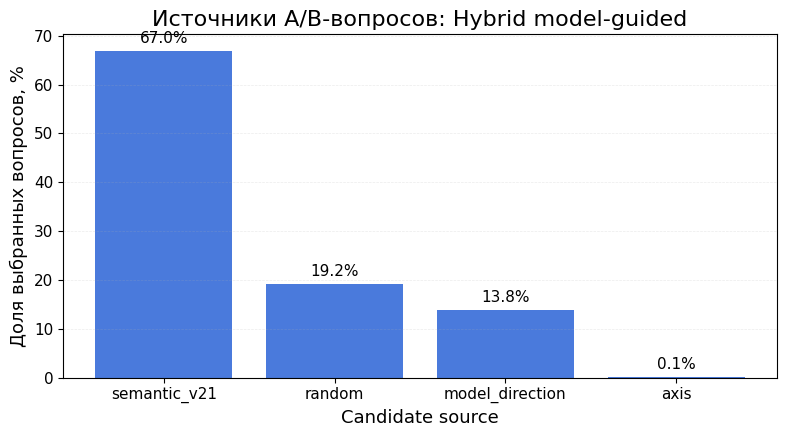

In [10]:
def plot_pair_sources(steps, strategy="hybrid_model_guided", target_mode="archetype8d"):
    df = steps[(steps["strategy"] == strategy) & (steps["target_mode"] == target_mode)].copy()
    counts = (
        df["pair_source"]
        .value_counts(normalize=True)
        .sort_values(ascending=False)
        .rename_axis("pair_source")
        .reset_index(name="share")
    )

    fig, ax = plt.subplots(figsize=(8, 4.5), facecolor="white")
    ax.bar(counts["pair_source"], counts["share"] * 100.0, alpha=0.9)
    for x, y in enumerate(counts["share"] * 100.0):
        ax.text(x, y + 1.0, f"{y:.1f}%", ha="center", va="bottom")
    ax.set_title(f"Источники A/B-вопросов: {MODEL_GUIDED_STRATEGY_DISPLAY_NAMES.get(strategy, strategy)}")
    ax.set_xlabel("Candidate source")
    ax.set_ylabel("Доля выбранных вопросов, %")
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / f"article_v4b_pair_sources_{strategy}.png", dpi=200, bbox_inches="tight")
    plt.show()

plot_pair_sources(steps, strategy="hybrid_model_guided", target_mode="archetype8d")

## Короткий вывод

Ниже ячейка формирует текстовый вывод после получения фактических чисел.


In [11]:
def best_by_mode(summary, method="heuristic_update"):
    df = summary[summary["final_vector_method"] == method].copy()
    return (
        df.sort_values("mean_final_distance")
        .groupby("target_mode")
        .head(1)[["target_mode", "strategy_display", "mean_final_distance"]]
        .sort_values("target_mode")
    )

best = best_by_mode(summary)
best

,target_mode,strategy_display,mean_final_distance
26,archetype8d,Semantic active v3,0.370540
27,random8d,Candidate pool active,1.020938
80,semantic4d,Semantic active v3,0.415562
107,semantic6d,Semantic active v3,0.548109


## Вывод по V4b model-guided Pair Generator

Эксперимент V4b проверял, может ли Logistic Preference Model использоваться не только для оценки финального preference vector, но и для выбора следующих A/B-пар. Были протестированы model-only и hybrid model-guided стратегии, где пары выбирались на основе model uncertainty и proxy-score.

Результаты показали, что полное доверие Preference Model при генерации пар пока неэффективно. Стратегии `model_only_cold`, `model_only_warmup` и `model_only_pretrained_prior` существенно уступают `Semantic active v3` на realistic-режиме `Archetype 8D`. Это указывает на проблему cold-start и на то, что неопределённость модели сама по себе не является достаточным критерием полезности A/B-вопроса.

Гибридные model-guided стратегии работают лучше model-only, однако также не превосходят `Semantic active v3`. Даже при использовании proxy-score и Preference Model selector в основном выбирает semantic-направления, но добавление random/model-direction вопросов размывает траекторию поиска и ухудшает итоговое расстояние до target.

При этом Preference Model остаётся полезной для формирования финального preference vector. Внутри `Hybrid model-guided` калиброванный вектор модели даёт меньшее final distance, чем heuristic update. Это подтверждает вывод V4a.2: модель хорошо извлекает направление предпочтений из A/B-истории, но пока эффективнее использовать её как дополнительный компонент финального state, а не как главный механизм выбора A/B-пар.

Итог: на текущем этапе основной стратегией Pair Generator остаётся `Semantic active v3`, а Preference Model целесообразно использовать для post-session correction / scale-calibrated final vector.